
### **VISULISATION AND INSIGHTS**


### **From here, the visualizations and insights will be developed based on the data that I have gathered, helping to better understand patterns, trends, and key information.**


In [153]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [150]:
import sys
sys.path.append('../Database')
from db import engine

### How many countries fall in each development Category

In [3]:
df_development_category= pd.read_sql("""
SELECT development_category ,COUNT(DISTINCT country) as country_count
FROM "World_Bank"
GROUP BY development_category 
ORDER BY country_count DESC
""",engine)
print(df_development_category)



  development_category  country_count
0             Moderate             44
1            Developed             30
2           Developing             29
3       Underdeveloped              8
4     Highly Developed              4
5            Very Poor              1


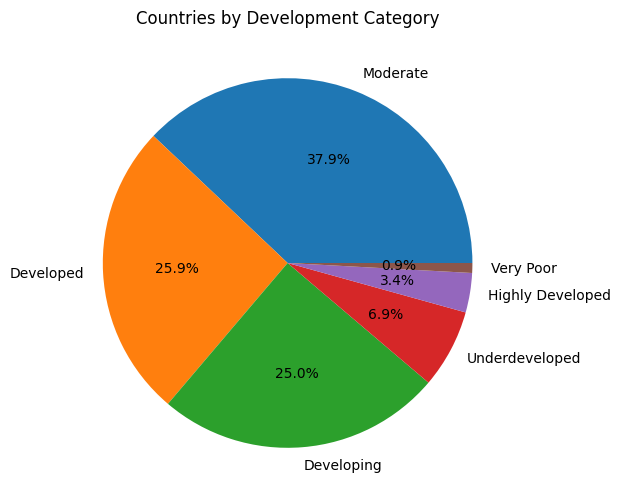

In [154]:
plt.figure(figsize=(10,6))
plt.pie(df_development_category['country_count'],labels=df_development_category['development_category'],autopct='%1.1f%%')
plt.title('Countries by Development Category')
plt.show()

#### The majority of world countries remain in moderate to developing stages, highlighting that global development is still a work in progress with significant inequality between nations

### How many countries in each GDP Category?

In [5]:
df_gdp_category= pd.read_sql("""
SELECT gdp_category ,COUNT(DISTINCT country) as country_count
FROM "World_Bank"
GROUP BY gdp_category
ORDER BY country_count DESC
""",engine)
print(df_gdp_category)

       gdp_category  country_count
0      Lower Middle             34
1        Low Income             26
2      Upper Middle             18
3       High Income             11
4  Very High Income              7


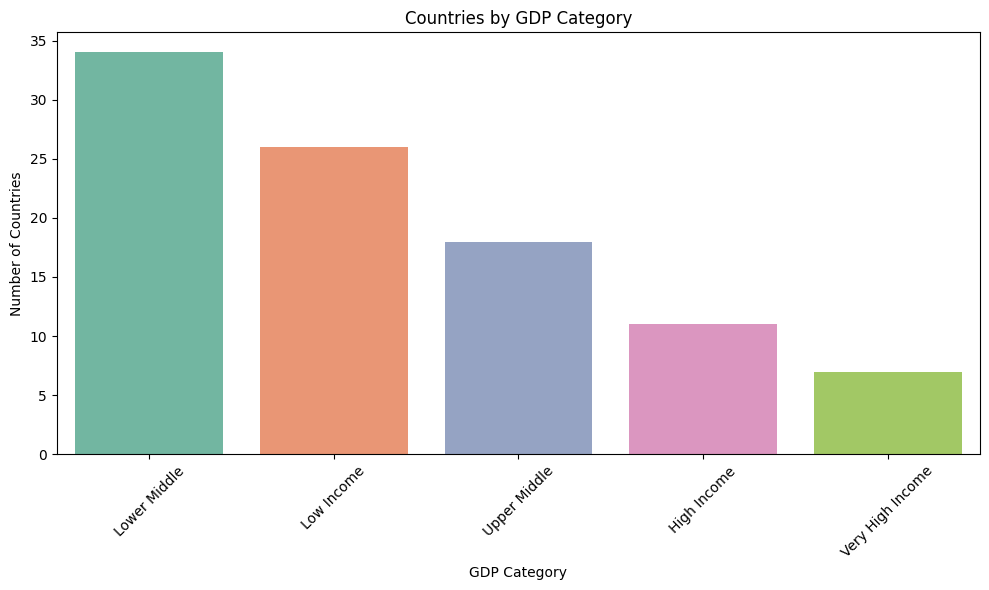

In [6]:
plt.figure(figsize=(10,6))
sns.barplot(x='gdp_category', y='country_count', data=df_gdp_category,hue='gdp_category',palette='Set2')
plt.title('Countries by GDP Category')
plt.xlabel('GDP Category')
plt.ylabel('Number of Countries')
plt.xticks(rotation=45) 
plt.tight_layout()
plt.show()

#### The majority of world countries fall in lower income categories, with only a handful of nations achieving very high income status — showing that global wealth is concentrated in very few countries

### Which sub region has the highest average gdp per capita?
### Where Should I invest?

In [7]:
df_highest_gdp_per_capita = pd.read_sql("""
SELECT sub_region,AVG(gdp_per_capita) as Average_gdp_per_capita
FROM "World_Bank"
GROUP BY sub_region
ORDER BY Average_gdp_per_capita DESC

""",engine)
print(df_highest_gdp_per_capita)

       sub_region  average_gdp_per_capita
0       East Asia            18460.304792
1       West Asia            16062.898635
2  Southeast Asia             9702.267348
3    Central Asia             3042.625167
4      South Asia             2179.385759


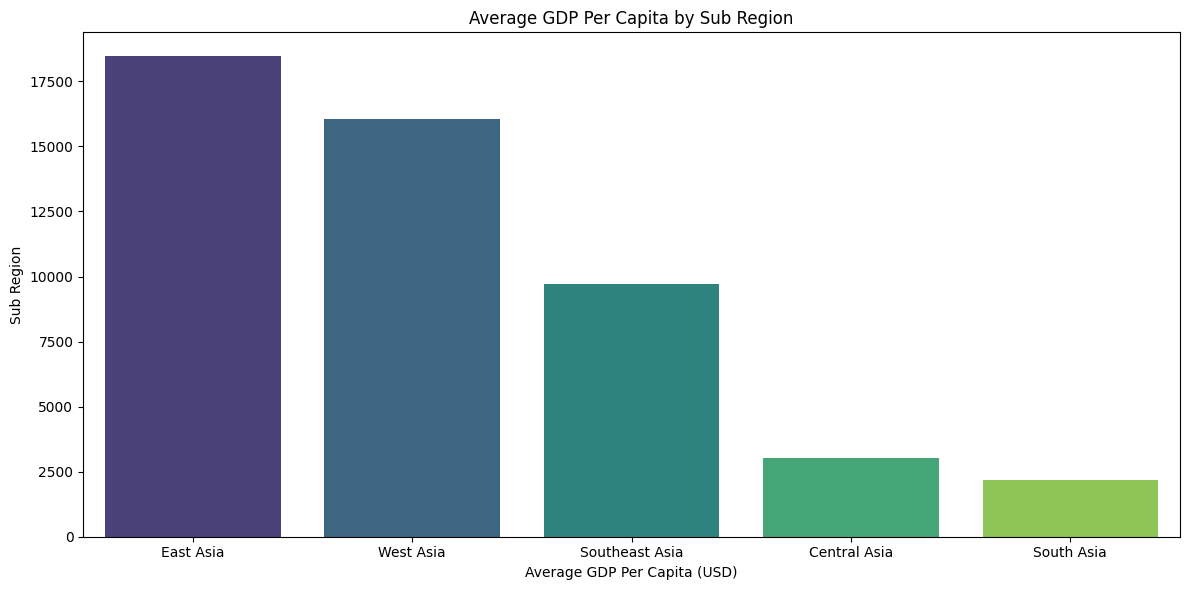

In [8]:
plt.figure(figsize=(12,6))
sns.barplot(x = 'sub_region',y='average_gdp_per_capita',data = df_highest_gdp_per_capita,hue='sub_region',palette='viridis')
plt.title('Average GDP Per Capita by Sub Region')
plt.xlabel('Average GDP Per Capita (USD)')
plt.ylabel('Sub Region')
plt.tight_layout()
plt.show()

#### The sharp gap between East/West Asia and South/Central Asia suggests uneven economic distribution, possibly due to differences in industrialization, natural resources (like oil in West Asia), and technological advancement. This indicates the need for focused economic policies and investment in lower-performing regions.

### Which countries had negative gdp growth most frequently?
### Which economies are unstable?

In [9]:
df_negative_gdp_growth = pd.read_sql("""
SELECT country,COUNT(*) AS negative_growth_count
FROM "World_Bank"
WHERE gdp_growth < 0
GROUP BY country
ORDER BY negative_growth_count DESC
LIMIT 10


""",engine)
print(df_negative_gdp_growth)

                country  negative_growth_count
0     Brunei Darussalam                      9
1  Syrian Arab Republic                      7
2           Timor-Leste                      7
3    West Bank and Gaza                      6
4               Lebanon                      6
5    Iran, Islamic Rep.                      5
6             Sri Lanka                      5
7       Kyrgyz Republic                      5
8                Kuwait                      5
9           Yemen, Rep.                      5


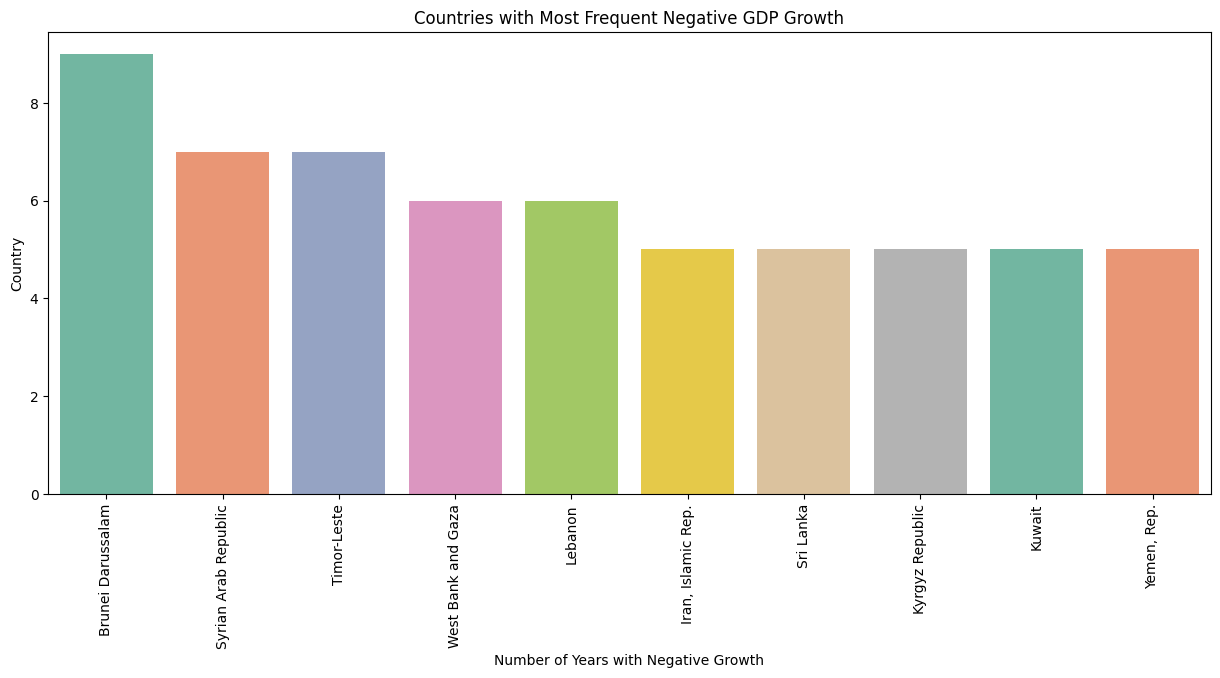

In [10]:
plt.figure(figsize=(15,6))
sns.barplot(x = 'country',y='negative_growth_count',data = df_negative_gdp_growth,hue='country',palette='Set2')
plt.title('Countries with Most Frequent Negative GDP Growth')
plt.xlabel('Number of Years with Negative Growth')
plt.ylabel('Country')
plt.xticks(rotation = 90)
plt.show()

#### The repeated negative GDP growth in these countries highlights structural economic vulnerabilities. For example, conflict-affected regions like the Syrian Arab Republic and Yemen, and resource-dependent economies like Brunei and Kuwait, are more prone to economic downturns. This suggests that diversification and political stability are key factors for sustained economic growth.

### How has global average gdp growth changed over years?
### Is the world getting richer?

In [11]:
df_average_gdp_growth = pd.read_sql("""
SELECT year,AVG(gdp_growth) as average_gdp
FROM "World_Bank"
GROUP BY year
ORDER BY  year 

""",engine)
print(df_average_gdp_growth)

    year  average_gdp
0   2000     7.058667
1   2001     3.543478
2   2002     4.609783
3   2003     5.876087
4   2004     8.384130
5   2005     6.820870
6   2006     7.798261
7   2007     7.985435
8   2008     5.891522
9   2009     3.118043
10  2010     6.598478
11  2011     5.750435
12  2012     4.837174
13  2013     4.528043
14  2014     4.200652
15  2015     3.185870
16  2016     3.974565
17  2017     3.621304
18  2018     3.817826
19  2019     4.059111
20  2020    -3.431778
21  2021     4.533778
22  2022     4.564222
23  2023     3.139535


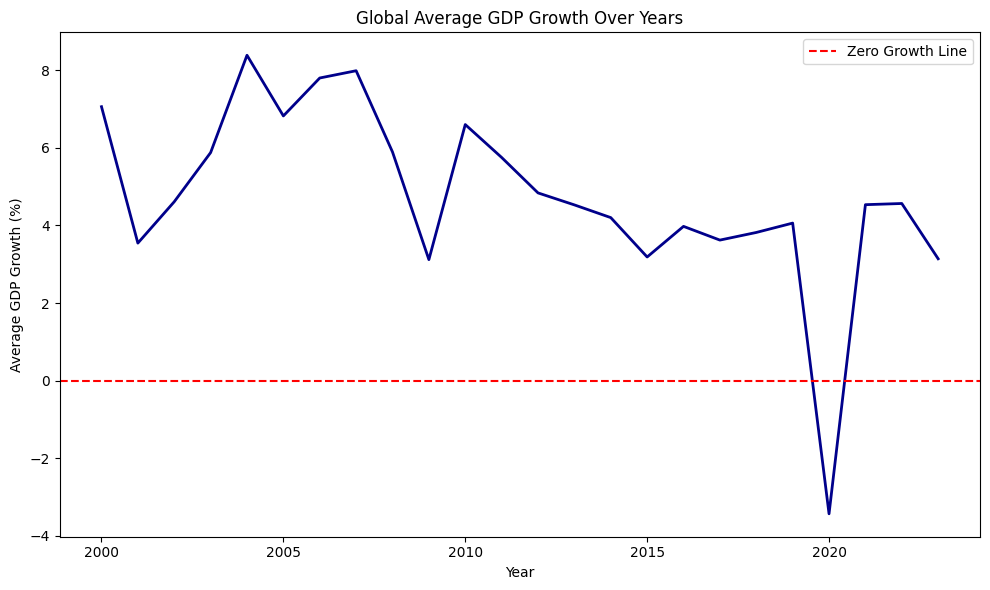

In [12]:
plt.figure(figsize=(10,6))
sns.lineplot(x = 'year',y='average_gdp',data = df_average_gdp_growth,color = 'darkblue',linewidth=2)
plt.title('Global Average GDP Growth Over Years')
plt.xlabel('Year')
plt.ylabel('Average GDP Growth (%)')
plt.axhline(y=0, color='red', linestyle='--', label='Zero Growth Line')
plt.legend()
plt.tight_layout()
plt.show()

#### The chart shows that global GDP growth has generally remained positive over the years, indicating overall economic expansion. However, there are noticeable fluctuations, with a peak during the mid-2000s followed by a decline around 2009, likely due to the global financial crisis. The most significant drop occurs in 2020, where GDP growth turns negative, reflecting the severe economic impact of the COVID-19 pandemic. Although there is a recovery after 2020, growth levels remain lower compared to earlier peaks, suggesting a gradual and uneven recovery.

### Which sub regions attract most FDI inflows?
### Where is foreign investment going?

In [13]:
df_fdi_inflows = pd.read_sql("""
SELECT sub_region,AVG(fdi_inflows) AS avg_fdi_inflows
FROM "World_Bank"
GROUP BY sub_region
ORDER BY  avg_fdi_inflows DESC 

""",engine)
print(df_fdi_inflows)

       sub_region  avg_fdi_inflows
0  Southeast Asia         4.885417
1    Central Asia         4.727500
2       East Asia         3.751250
3       West Asia         3.541718
4      South Asia         1.885393


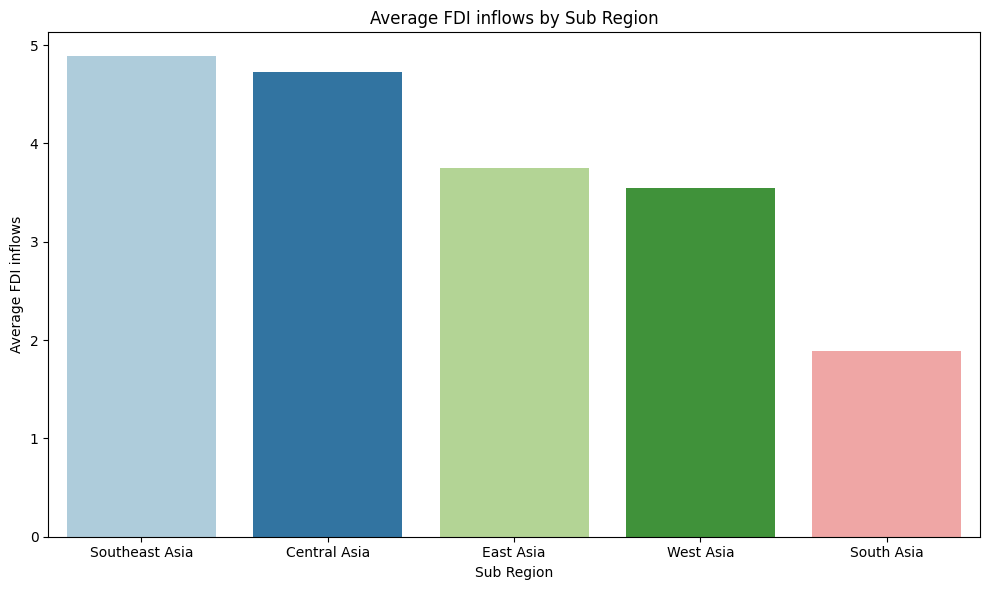

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(x = 'sub_region',y='avg_fdi_inflows',data = df_fdi_inflows,hue='sub_region',palette="Paired")
plt.title('Average FDI inflows by Sub Region')
plt.xlabel('Sub Region')
plt.ylabel('Average FDI inflows')
plt.tight_layout()
plt.show()

#### The higher FDI inflows in Southeast Asia highlight its role as a global manufacturing and investment hub, whereas South Asia’s low inflows indicate untapped potential and possible barriers such as regulatory challenges and infrastructure gaps. This disparity reflects uneven investment distribution across Asian sub-regions.

### Relationship between FDI inflows and GDP growth?
### Does investment boost economy?

In [15]:
df_relation_fdi_gdp = pd.read_sql("""
SELECT fdi_inflows,gdp_growth
FROM "World_Bank"
WHERE fdi_inflows IS NOT NULL
AND gdp_growth IS NOT NULL

""",engine)

In [16]:
print(df_relation_fdi_gdp[['fdi_inflows','gdp_growth']].corr())

             fdi_inflows  gdp_growth
fdi_inflows     1.000000    0.163664
gdp_growth      0.163664    1.000000


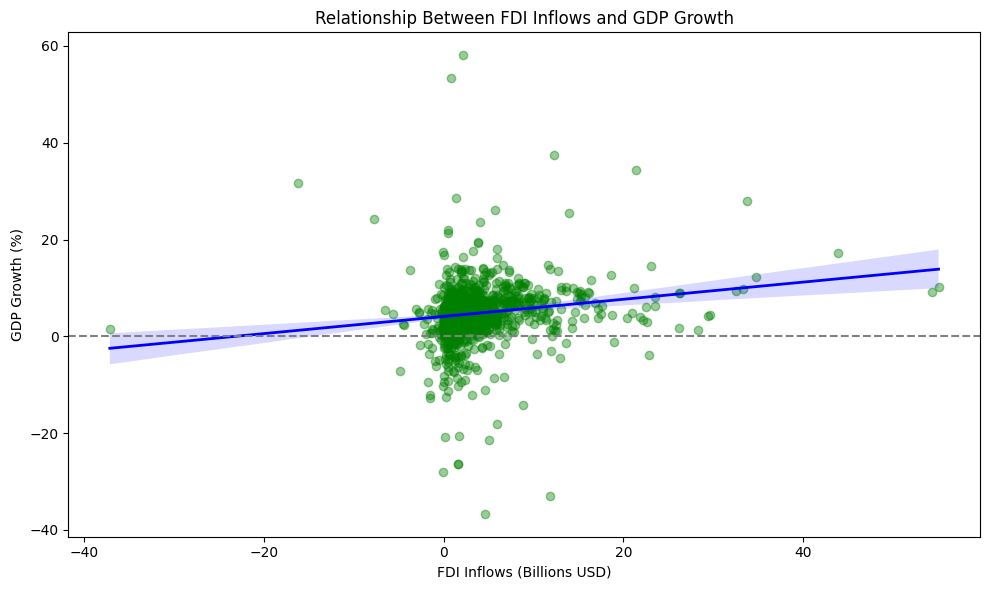

In [17]:
plt.figure(figsize=(10,6))
sns.regplot(x='fdi_inflows', y='gdp_growth', data=df_relation_fdi_gdp, 
            scatter_kws={'alpha':0.4, 'color':'green'}, 
            line_kws={'color':'blue', 'linewidth':2})
plt.xlabel('FDI Inflows (Billions USD)')
plt.ylabel('GDP Growth (%)')
plt.title('Relationship Between FDI Inflows and GDP Growth')
plt.axhline(y=0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

#### Although there is a positive correlation between FDI and GDP growth, the presence of significant variability and outliers suggests that FDI alone is not a decisive factor. Economic growth depends on multiple variables such as political stability, infrastructure, and domestic policies. This indicates a weak-to-moderate correlation rather than a strong one.

#### There is a weak positive relationship between FDI inflows and GDP growth — meaning more FDI slightly tends to increase growth, but it is not a strong or guaranteed effect

### GDP distribution across categories

In [18]:
df_gdp_across_categories = pd.read_sql("""
SELECT gdp_category,gdp_per_capita
FROM "World_Bank"
WHERE gdp_per_capita IS NOT NULL
AND gdp_category !='nan'
""",engine)
print(df_gdp_across_categories)

      gdp_category  gdp_per_capita
0       Low Income          138.71
1       Low Income          178.95
2       Low Income          198.87
3       Low Income          221.76
4       Low Income          254.18
...            ...             ...
1091  Lower Middle         1430.16
1092  Lower Middle         1362.17
1093    Low Income          975.36
1094    Low Income          811.17
1095    Low Income          633.89

[1096 rows x 2 columns]


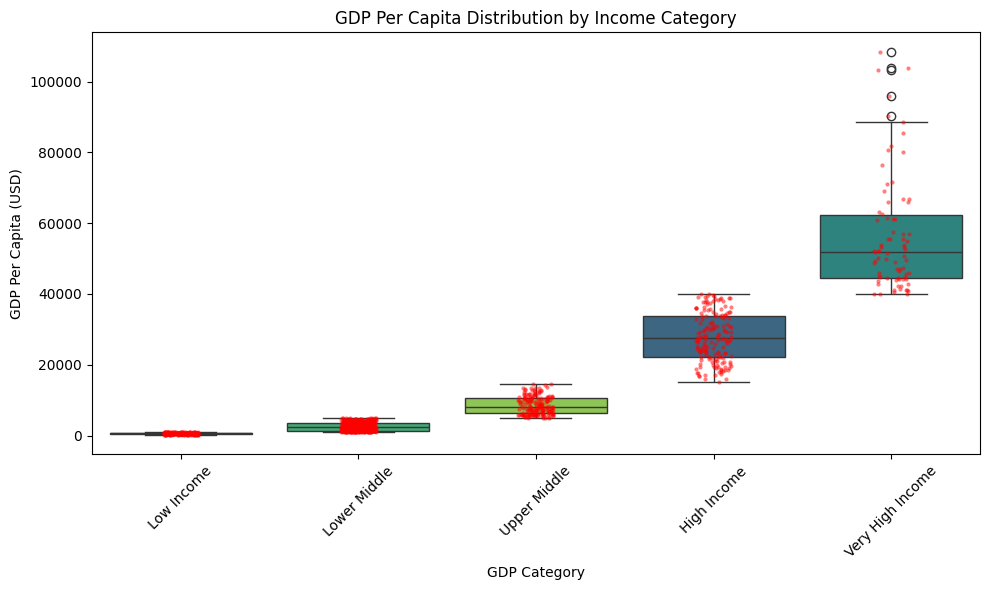

In [155]:
plt.figure(figsize=(10,6))
sns.boxplot(x='gdp_category',y='gdp_per_capita',data = df_gdp_across_categories,order=['Low Income', 'Lower Middle', 
                     'Upper Middle', 'High Income', 'Very High Income'],hue='gdp_category',palette='viridis',width=0.8)
sns.stripplot(x='gdp_category',y='gdp_per_capita',data = df_gdp_across_categories, order=['Low Income', 'Lower Middle', 
                     'Upper Middle', 'High Income', 'Very High Income'],color='red', size=3, alpha=0.5,jitter=True)
plt.title('GDP Per Capita Distribution by Income Category')
plt.xlabel('GDP Category')
plt.ylabel('GDP Per Capita (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### GDP per capita increases significantly as we move from low-income to very high-income categories. Low-income countries have very low and tightly clustered GDP values, while higher-income groups show greater variability. The very high-income category has the highest median GDP per capita and also contains several outliers, indicating some countries have exceptionally high income levels.

###  Health

### Which sub region has highest life expectancy?

In [91]:
df_life_expectancy = pd.read_sql("""
SELECT sub_region,life_expectancy
FROM "World_Bank"
WHERE life_expectancy IS NOT NULL
""",engine)
print(df_life_expectancy)

      sub_region  life_expectancy
0     South Asia             55.5
1     South Asia             56.2
2     South Asia             57.2
3     South Asia             57.8
4     South Asia             58.2
...          ...              ...
1091   West Asia             68.0
1092   West Asia             66.8
1093   West Asia             67.1
1094   West Asia             67.1
1095   West Asia             65.9

[1096 rows x 2 columns]


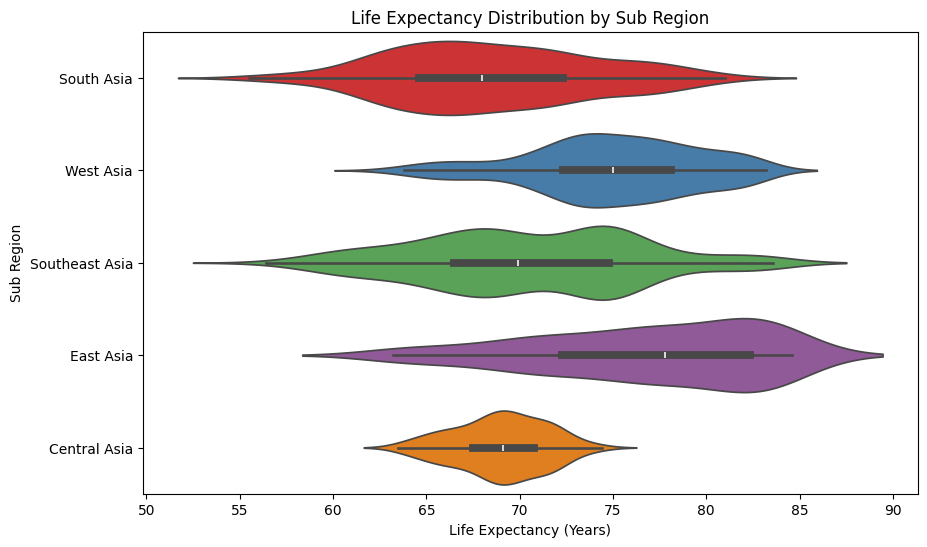

In [95]:
plt.figure(figsize=(10,6))
sns.violinplot(x='life_expectancy',y='sub_region',data = df_life_expectancy,hue='sub_region',palette='Set1')
plt.title("Life Expectancy Distribution by Sub Region")
plt.xlabel("Life Expectancy (Years)")
plt.ylabel("Sub Region")
plt.show()

#### Regions like East Asia and West Asia have higher life expectancy because they generally have better healthcare systems, higher incomes, improved nutrition, and better living conditions. In contrast, regions like South Asia and Central Asia have lower life expectancy due to limited access to quality healthcare, lower income levels, and higher rates of disease. Differences in education, sanitation, and government investment in public health also contribute to the variation across sub-regions.

### Which regions have highest infant mortality?

In [25]:
df_infant_mortality = pd.read_sql("""
SELECT sub_region,AVG(infant_mortality) AS avg_infant_mortality
FROM "World_Bank"
GROUP BY sub_region

""",engine)
print(df_infant_mortality)

       sub_region  avg_infant_mortality
0  Southeast Asia             27.351894
1    Central Asia             28.605000
2       West Asia             16.187765
3       East Asia             10.484375
4      South Asia             39.848691


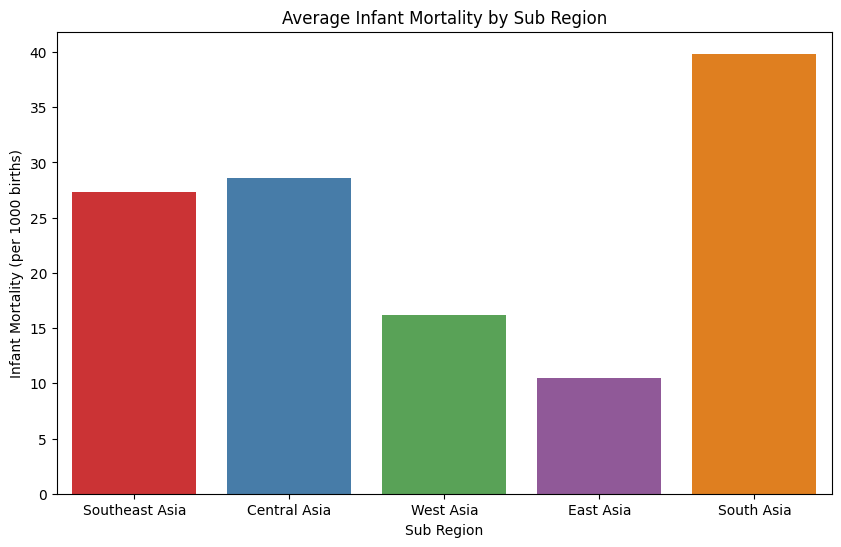

In [101]:
plt.figure(figsize=(10,6))
sns.barplot(x='sub_region',y='avg_infant_mortality',data = df_infant_mortality,hue='sub_region',palette='Set1')
plt.title('Average Infant Mortality by Sub Region')
plt.xlabel('Sub Region')
plt.ylabel('Infant Mortality (per 1000 births)')
plt.show()

#### South Asia records the highest infant mortality rate among all sub-regions, while East Asia has the lowest. Central and Southeast Asia fall in the middle range. This highlights major regional inequalities in healthcare access, maternal care, nutrition, and sanitation. Lower mortality in East Asia suggests better healthcare systems and living standards, whereas higher rates in South Asia indicate developmental challenges.

### Relationship between gdp per capita and life expectancy?

In [28]:
df_gdp_life_expectancy = pd.read_sql("""
SELECT gdp_per_capita,life_expectancy
FROM "World_Bank"
WHERE gdp_per_capita IS NOT NULL
AND life_expectancy IS NOT NULL

""",engine)
print(df_gdp_life_expectancy)

      gdp_per_capita  life_expectancy
0             138.71             55.5
1             178.95             56.2
2             198.87             57.2
3             221.76             57.8
4             254.18             58.2
...              ...              ...
1091         1430.16             68.0
1092         1362.17             66.8
1093          975.36             67.1
1094          811.17             67.1
1095          633.89             65.9

[1096 rows x 2 columns]


In [29]:
print(df_gdp_life_expectancy[['gdp_per_capita','life_expectancy']].corr())

                 gdp_per_capita  life_expectancy
gdp_per_capita          1.00000          0.69861
life_expectancy         0.69861          1.00000


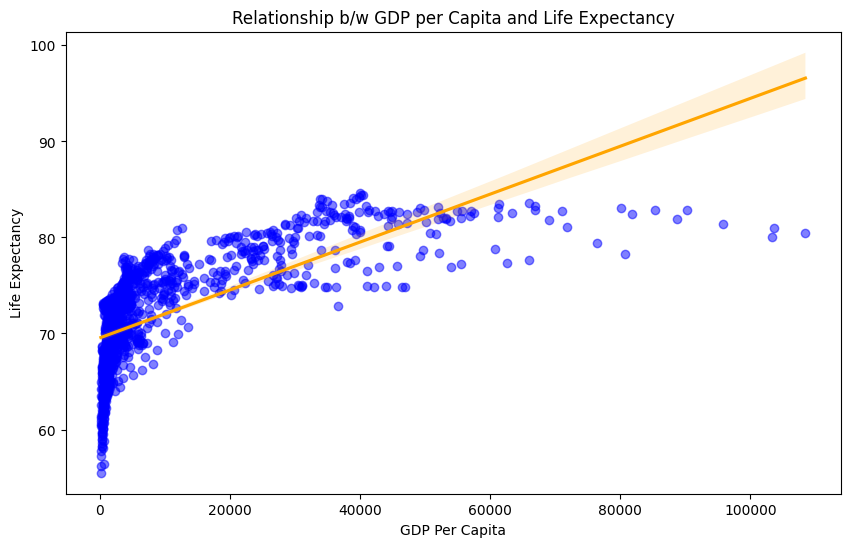

In [104]:
plt.figure(figsize=(10,6))
sns.regplot(x='gdp_per_capita',y='life_expectancy',data = df_gdp_life_expectancy,scatter_kws={'alpha':0.5,'color':'blue'}
           ,line_kws={'color':'orange'})
plt.title("Relationship b/w GDP per Capita and Life Expectancy")
plt.xlabel("GDP Per Capita")
plt.ylabel("Life Expectancy")
plt.show()

#### The scatter plot shows a clear positive relationship between GDP per capita and life expectancy. As income levels increase, life expectancy also rises, especially at lower income levels. However, at higher GDP levels, the increase in life expectancy becomes more gradual, suggesting diminishing returns. This indicates that economic growth strongly impacts health outcomes, but other factors like healthcare quality and lifestyle also play a role at higher income levels.

### Compare life expectancy trends across different countries over time?

In [106]:
df_life_expectancy = pd.read_sql("""
SELECT year,country,AVG(life_expectancy) AS avg_life
FROM "World_Bank"
WHERE country IN ('India','China','Japan','Nepal','Israel','Pakistan','Saudi Arabia')
GROUP BY year,country
ORDER BY year

""",engine)
print(df_life_expectancy)

     year       country  avg_life
0    2000         India      62.7
1    2000  Saudi Arabia      72.6
2    2000         China      72.3
3    2000         Japan      81.1
4    2000        Israel      79.0
..    ...           ...       ...
163  2023        Israel      83.2
164  2023         Japan      84.0
165  2023         India      72.0
166  2023  Saudi Arabia      78.7
167  2023         China      78.0

[168 rows x 3 columns]


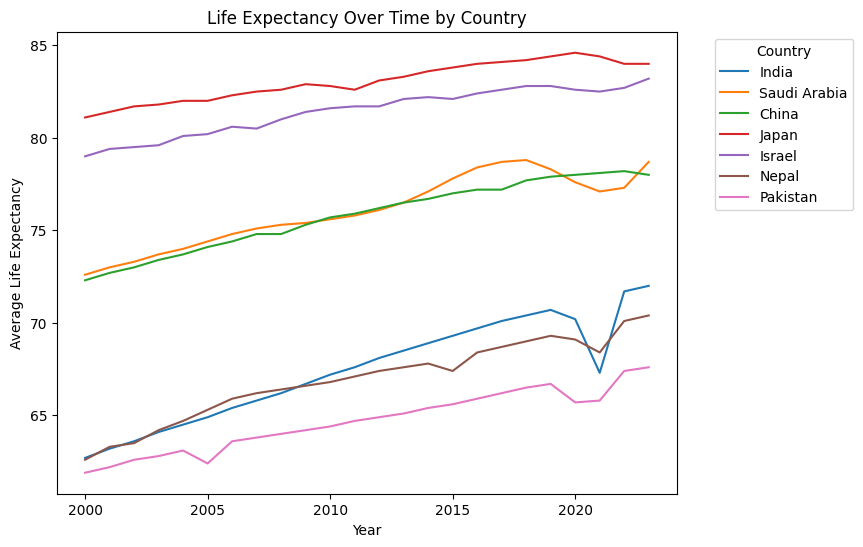

In [107]:
plt.figure(figsize=(8,6))
sns.lineplot(data = df_life_expectancy,x = 'year',y='avg_life',hue = 'country')
plt.title('Life Expectancy Over Time by Country')
plt.xlabel('Year')
plt.ylabel('Average Life Expectancy')
plt.legend(title='Country',bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

#### All countries show a steady improvement in life expectancy over time, reflecting advancements in healthcare, nutrition, and living conditions. Developed countries like Japan and Israel consistently maintain higher life expectancy, while countries like India, Pakistan, and Nepal show gradual but noticeable progress. Temporary dips (if any) may reflect external factors such as health crises or economic challenges.

### Which sub region has lowest secondary school enrolment?

In [35]:
df_secondary_enrolment = pd.read_sql("""
SELECT sub_region,AVG(school_enrolment_secondary) AS avg_enrolment
FROM "World_Bank"
GROUP BY sub_region
ORDER BY avg_enrolment ASC
""",engine)
print(df_secondary_enrolment)

       sub_region  avg_enrolment
0      South Asia      59.527178
1  Southeast Asia      74.296595
2       West Asia      87.918391
3    Central Asia      89.800108
4       East Asia      93.997042


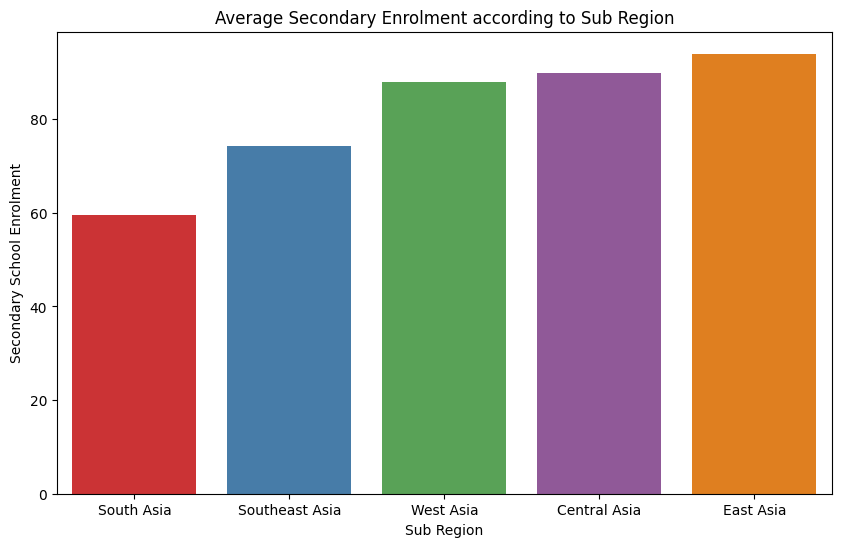

In [108]:
plt.figure(figsize=(10,6))
sns.barplot(x='sub_region',y='avg_enrolment',data = df_secondary_enrolment,hue='sub_region',palette='Set1')
plt.title('Average Secondary Enrolment according to Sub Region')
plt.xlabel('Sub Region')
plt.ylabel('Secondary School Enrolment')
plt.show()

#### Secondary school enrollment is highest in East Asia, followed by Central and West Asia, indicating better access to higher levels of education in these regions. South Asia has the lowest enrollment, suggesting barriers such as poverty, limited infrastructure, and social factors. This gap highlights inequalities in educational opportunities across regions.

### Relationship between education index and gdp per capita?

In [38]:
df_education_gdp = pd.read_sql("""
SELECT gdp_per_capita,education_index
FROM "World_Bank"
WHERE gdp_per_capita IS NOT NULL
AND education_index IS NOT NULL

""",engine)
print(df_education_gdp)

      gdp_per_capita  education_index
0             138.71           18.090
1             178.95           66.411
2             198.87           54.648
3             221.76           62.344
4             254.18           59.889
...              ...              ...
1091         1430.16           94.265
1092         1362.17           94.265
1093          975.36           60.333
1094          811.17           94.265
1095          633.89           94.265

[1096 rows x 2 columns]


In [39]:
print(df_education_gdp[['education_index','gdp_per_capita']].corr())

                 education_index  gdp_per_capita
education_index          1.00000         0.35994
gdp_per_capita           0.35994         1.00000


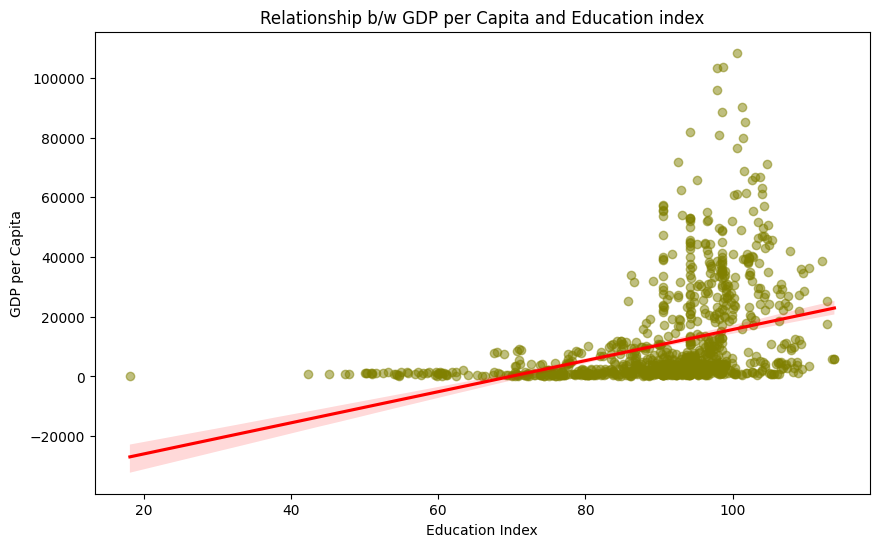

In [109]:
plt.figure(figsize=(10,6))
sns.regplot(x='education_index',y='gdp_per_capita',data = df_education_gdp,scatter_kws={'alpha':0.5,'color':'olive'}
           ,line_kws={'color':'red'})
plt.title("Relationship b/w GDP per Capita and Education index")
plt.xlabel("Education Index")
plt.ylabel("GDP per Capita")
plt.show()

#### There is a positive correlation between the education index and GDP per capita, meaning countries with higher education levels tend to have stronger economies. However, the data also shows variability, indicating that while education is a key factor, other elements like governance, resources, and industrialization also influence economic performance.

### Primary vs secondary school enrolment gap by sub region?

In [42]:
df_enrolment_gap = pd.read_sql("""
SELECT sub_region,
ROUND(AVG(school_enrolment_primary)::numeric,2) AS avg_primary
,ROUND(AVG(school_enrolment_secondary)::numeric,2) AS avg_secondary,
ROUND((AVG(school_enrolment_primary)-AVG(school_enrolment_secondary))::numeric,2) AS enrolment_gap
FROM "World_Bank"
GROUP BY sub_region
ORDER BY enrolment_gap

""",engine)
print(df_enrolment_gap)

       sub_region  avg_primary  avg_secondary  enrolment_gap
0       East Asia       100.94          94.00           6.95
1    Central Asia        97.30          89.80           7.50
2       West Asia        98.72          87.92          10.80
3  Southeast Asia       106.54          74.30          32.24
4      South Asia       101.28          59.53          41.75


In [43]:
df_melted = df_enrolment_gap.melt(
    id_vars='sub_region',
    value_vars=['avg_primary','avg_secondary'],
    var_name = 'type',
    value_name='enrolment'
)
df_melted

,sub_region,type,enrolment
0,East Asia,avg_primary,100.94
1,Central Asia,avg_primary,97.30
2,West Asia,avg_primary,98.72
3,Southeast Asia,avg_primary,106.54
4,South Asia,avg_primary,101.28
5,East Asia,avg_secondary,94.00
6,Central Asia,avg_secondary,89.80
7,West Asia,avg_secondary,87.92
8,Southeast Asia,avg_secondary,74.30
9,South Asia,avg_secondary,59.53


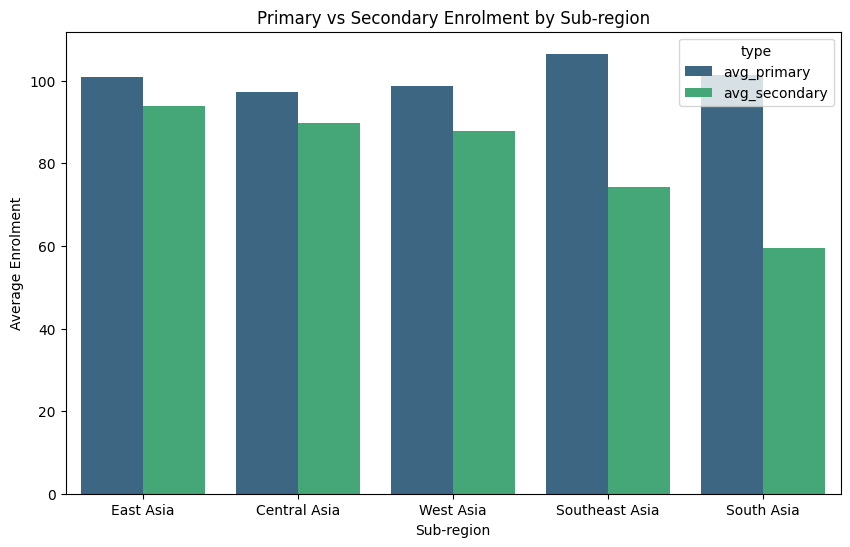

In [113]:
plt.figure(figsize=(10,6))
sns.barplot(
    data = df_melted,
    x = 'sub_region',
    y = 'enrolment',
    hue ='type',
    palette='viridis'
)
plt.title('Primary vs Secondary Enrolment by Sub-region')
plt.xlabel('Sub-region')
plt.ylabel('Average Enrolment')

plt.show()
    

#### Primary school enrollment is consistently high across all sub-regions, indicating strong access to basic education. However, there is a noticeable drop when it comes to secondary education, especially in South Asia. This suggests that while children are enrolled in early education, many do not continue to higher levels due to economic or social constraints.

### How is education expenditure distributed by sub region?

In [46]:
df_education_expenditure = pd.read_sql("""
SELECT sub_region,education_expenditure
FROM "World_Bank"
WHERE education_expenditure IS NOT NULL
AND sub_region !='nan'
""",engine)
print(df_education_expenditure)

      sub_region  education_expenditure
0     South Asia                  3.378
1     South Asia                  3.378
2     South Asia                  3.378
3     South Asia                  3.378
4     South Asia                  3.378
...          ...                    ...
1091   West Asia                  3.511
1092   West Asia                  3.511
1093   West Asia                  3.511
1094   West Asia                  3.511
1095   West Asia                  3.511

[1096 rows x 2 columns]


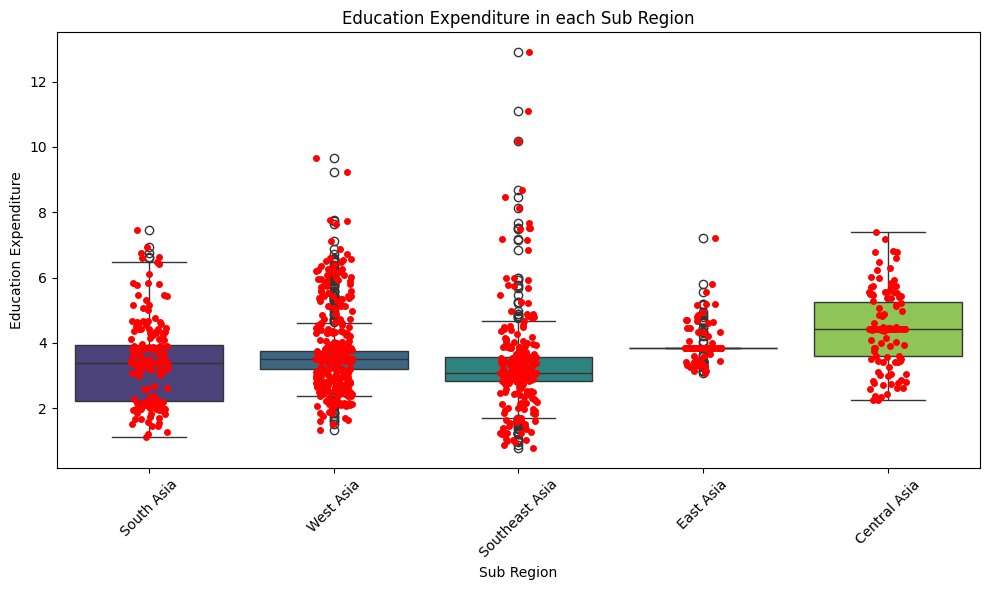

In [129]:
plt.figure(figsize=(10,6))
sns.boxplot(x='sub_region',y='education_expenditure',data = df_education_expenditure,hue='sub_region',palette='viridis',width=0.8)
sns.stripplot(x='sub_region',y='education_expenditure',data = df_education_expenditure,color='red')
plt.title('Education Expenditure in each Sub Region')
plt.xlabel('Sub Region')
plt.ylabel('Education Expenditure')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Education expenditure varies significantly across sub-regions. Central and West Asia tend to have higher and more consistent spending, while South Asia shows lower expenditure levels. Southeast Asia shows a wider spread, indicating variability among countries. Higher spending generally supports better education systems, though efficiency of spending also matters.

### Environment


### Top 10 countries by renewable energy usage?

In [50]:
df_renewable_energy = pd.read_sql("""
SELECT country,AVG(renewable_energy) AS avg_renewable_energy
FROM "World_Bank"
GROUP BY country
ORDER BY avg_renewable_energy DESC
LIMIT 10

""",engine)
print(df_renewable_energy)

      country  avg_renewable_energy
0      Bhutan             83.891667
1       Nepal             81.650000
2     Myanmar             71.304167
3    Cambodia             64.575000
4     Lao PDR             62.122917
5   Sri Lanka             55.345833
6  Tajikistan             49.366667
7    Pakistan             46.616667
8  Bangladesh             41.120833
9       India             39.129167


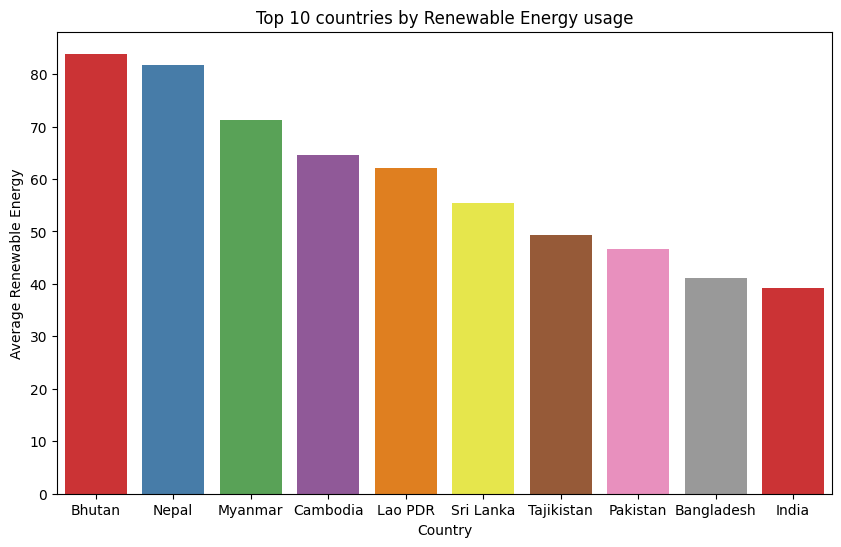

In [137]:
plt.figure(figsize=(10,6))
sns.barplot(x='country',y='avg_renewable_energy',data = df_renewable_energy,hue='country',palette='Set1')
plt.title('Top 10 countries by Renewable Energy usage')
plt.xlabel('Country')
plt.ylabel('Average Renewable Energy')
plt.show()

#### Countries like Bhutan and Nepal have the highest renewable energy usage, while India and Bangladesh have lower usage among the top 10. This suggests that smaller or less industrialized countries rely more on renewable sources, while larger economies depend more on non-renewable energy.

### GDP vs renewable energy relationship?

In [53]:
df_gdp_renewable = pd.read_sql("""
SELECT gdp_per_capita,renewable_energy
FROM "World_Bank"
WHERE gdp_per_capita IS NOT NULL
AND renewable_energy IS NOT NULL

""",engine)
print(df_gdp_renewable)

      gdp_per_capita  renewable_energy
0             138.71              45.6
1             178.95              37.8
2             198.87              36.7
3             221.76              44.2
4             254.18              33.9
...              ...               ...
1091         1430.16               0.8
1092         1362.17               2.0
1093          975.36               2.6
1094          811.17               3.0
1095          633.89               2.9

[1096 rows x 2 columns]


In [54]:
print(df_gdp_renewable[['gdp_per_capita','renewable_energy']].corr())

                  gdp_per_capita  renewable_energy
gdp_per_capita          1.000000         -0.404453
renewable_energy       -0.404453          1.000000


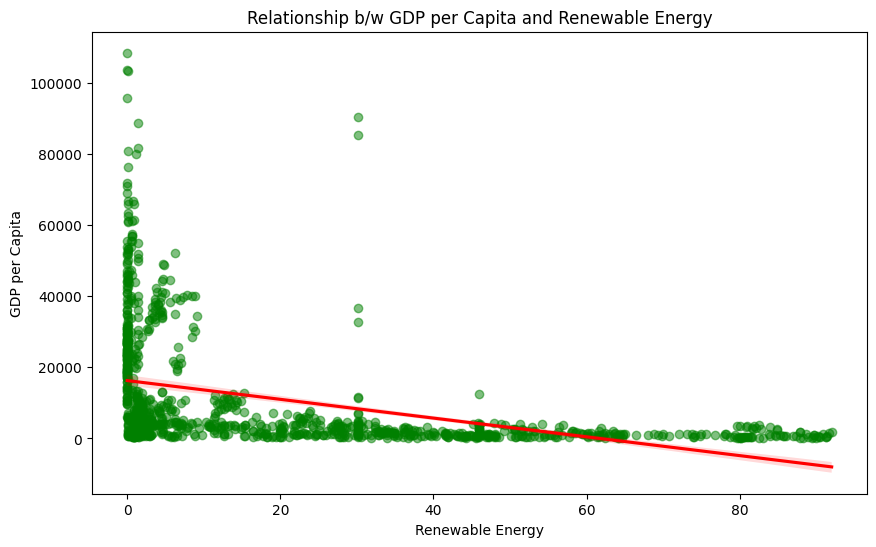

In [138]:
plt.figure(figsize=(10,6))
sns.regplot(x='renewable_energy',y='gdp_per_capita',data = df_gdp_renewable,scatter_kws={'alpha':0.5,'color':'green'}
           ,line_kws={'color':'red'})
plt.title("Relationship b/w GDP per Capita and Renewable Energy")
plt.xlabel("Renewable Energy")
plt.ylabel("GDP per Capita")
plt.show()

#### There is a negative relationship between GDP per capita and renewable energy usage. Countries with lower income tend to use more renewable energy, while richer countries often rely more on non-renewable sources like fossil fuels.

### How has clean water access changed over time globally?

In [57]:
df_clean_water = pd.read_sql("""
SELECT year,AVG(clean_water_access) as average_clean_water
FROM "World_Bank"
GROUP BY year
ORDER BY  year 

""",engine)
print(df_clean_water)

    year  average_clean_water
0   2000            85.254022
1   2001            84.472587
2   2002            84.179739
3   2003            84.729522
4   2004            85.278261
5   2005            85.831848
6   2006            86.389239
7   2007            86.947435
8   2008            87.504326
9   2009            88.061717
10  2010            88.612696
11  2011            89.151304
12  2012            89.685370
13  2013            90.215978
14  2014            90.744609
15  2015            91.268696
16  2016            91.783457
17  2017            92.291652
18  2018            92.797087
19  2019            93.884756
20  2020            94.318289
21  2021            94.726644
22  2022            95.093244
23  2023            95.371186


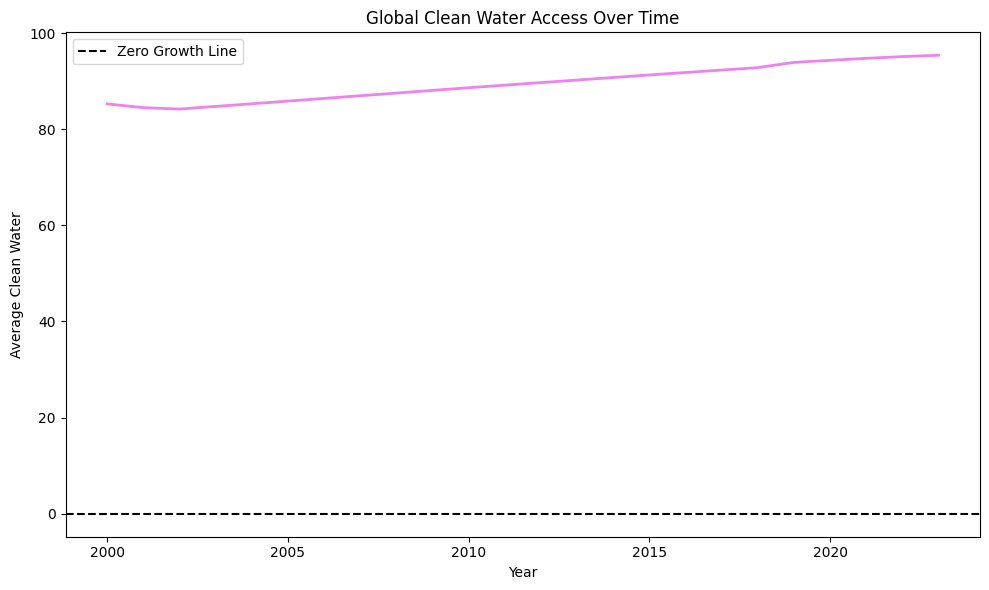

In [139]:
plt.figure(figsize=(10,6))
sns.lineplot(x = 'year',y='average_clean_water',data = df_clean_water,color = 'violet',linewidth=2)
plt.title('Global Clean Water Access Over Time')
plt.xlabel('Year')
plt.ylabel('Average Clean Water')
plt.axhline(y=0, color='black', linestyle='--', label='Zero Growth Line')
plt.legend()
plt.tight_layout()
plt.show()

#### Access to clean water has steadily increased over time, showing global improvement in basic living conditions and infrastructure. This reflects better government policies and investment in public health.

### Which sub region has highest female labour participation?

In [60]:
df_female_labour = pd.read_sql("""
SELECT sub_region,female_labour
FROM "World_Bank"
WHERE sub_region IS NOT NULL 
AND female_labour IS NOT NULL

""",engine)
print(df_female_labour)

      sub_region  female_labour
0     South Asia         14.196
1     South Asia         14.152
2     South Asia         14.154
3     South Asia         14.205
4     South Asia         14.302
...          ...            ...
1091   West Asia          6.011
1092   West Asia          5.207
1093   West Asia          5.117
1094   West Asia          5.041
1095   West Asia          4.987

[1096 rows x 2 columns]


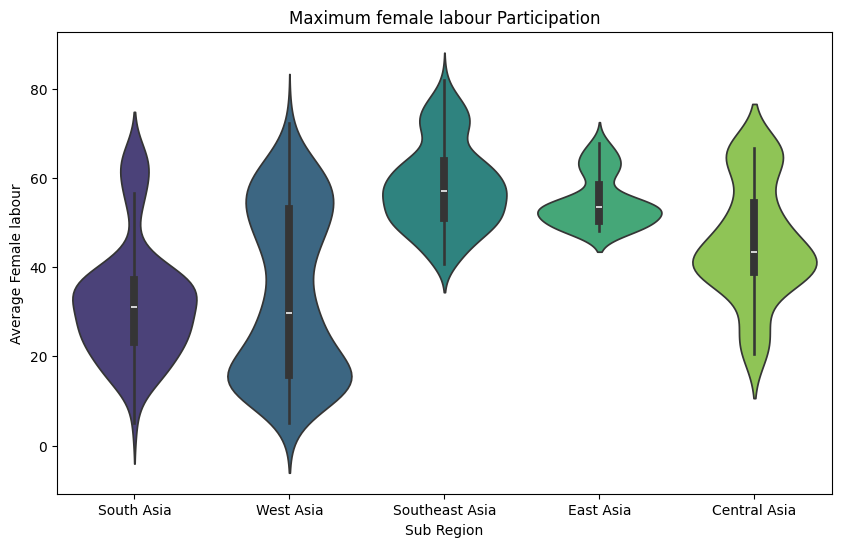

In [140]:
plt.figure(figsize=(10,6))
sns.violinplot(x = 'sub_region',y='female_labour',data = df_female_labour,hue = 'sub_region',palette='viridis')
plt.title('Maximum female labour Participation')
plt.xlabel('Sub Region')
plt.ylabel('Average Female labour')
plt.show()

#### Southeast Asia and East Asia show higher female labour participation, while South and West Asia have lower participation levels. This indicates differences in gender equality, cultural factors,employment opportunities and policy barriers that prevent women from entering the workforce in South Asian countries

### Relationship between gender index and gdp per capita?

In [63]:
df_gender_gdp = pd.read_sql("""
SELECT gender_index,gdp_per_capita
FROM "World_Bank"
WHERE gender_index IS NOT NULL 
AND gdp_per_capita IS NOT NULL

""",engine)
print(df_gender_gdp)

      gender_index  gdp_per_capita
0            8.668          138.71
1            8.984          178.95
2            8.835          198.87
3            8.806          221.76
4           14.053          254.18
...            ...             ...
1091         2.448         1430.16
1092         2.070         1362.17
1093         1.979          975.36
1094         2.014          811.17
1095         1.996          633.89

[1096 rows x 2 columns]


In [64]:
print(df_gender_gdp[['gender_index','gdp_per_capita']].corr())

                gender_index  gdp_per_capita
gender_index        1.000000        0.128791
gdp_per_capita      0.128791        1.000000


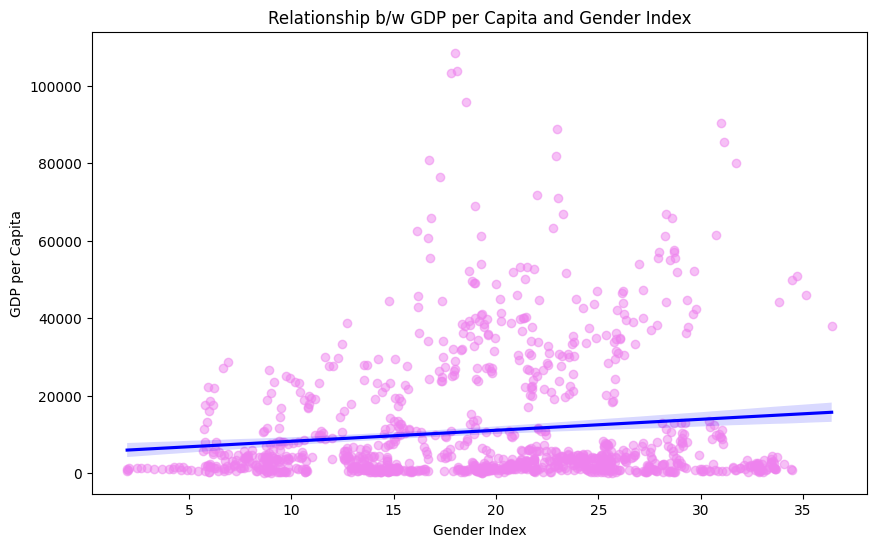

In [141]:
plt.figure(figsize=(10,6))
sns.regplot(x='gender_index',y='gdp_per_capita',data = df_gender_gdp,scatter_kws={'alpha':0.5,'color':'violet'}
           ,line_kws={'color':'blue'})
plt.title("Relationship b/w GDP per Capita and Gender Index")
plt.xlabel("Gender Index")
plt.ylabel("GDP per Capita")
plt.show()

#### There is a slight positive relationship between gender equality and GDP per capita. Countries with better gender equality tend to have higher income levels, although the relationship is not very strong.

### How has women parliament representation changed over time

In [67]:
df_women_parliament = pd.read_sql("""
SELECT year,AVG(women_parliament) as average_women_parliament
FROM "World_Bank"
GROUP BY year
ORDER BY  year 

""",engine)
print(df_women_parliament)

    year  average_women_parliament
0   2000                  9.547733
1   2001                 10.243261
2   2002                 10.403391
3   2003                 10.226957
4   2004                 10.240348
5   2005                 11.034130
6   2006                 11.288109
7   2007                 13.289065
8   2008                 13.554848
9   2009                 14.270739
10  2010                 14.178326
11  2011                 14.465283
12  2012                 15.174870
13  2013                 15.282174
14  2014                 15.515217
15  2015                 15.747609
16  2016                 15.917609
17  2017                 16.263783
18  2018                 16.481652
19  2019                 18.200267
20  2020                 19.130622
21  2021                 19.312200
22  2022                 19.400222
23  2023                 19.505767


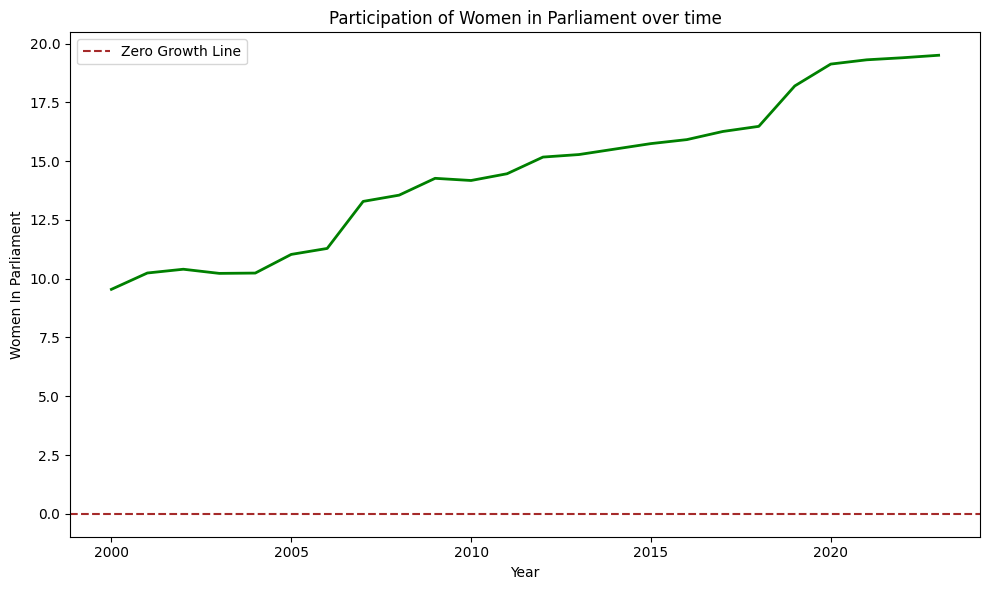

In [142]:
plt.figure(figsize=(10,6))
sns.lineplot(x = 'year',y='average_women_parliament',data = df_women_parliament,color = 'green',linewidth=2)
plt.title('Participation of Women in Parliament over time')
plt.xlabel('Year')
plt.ylabel('Women In Parliament')
plt.axhline(y=0, color='brown', linestyle='--', label='Zero Growth Line')
plt.legend()
plt.tight_layout()
plt.show()

#### The participation of women in parliament has increased over time, showing gradual progress toward gender equality in political representation.

### Overall analysis

### What drives human development? Correlation between all numeric columns?

In [71]:
df_corr = pd.read_sql("""
SELECT gdp_per_capita, gdp_growth, life_expectancy,infant_mortality,
       education_index,environment_index,gender_index,development_index,health_index
       internet_users,renewable_energy,female_labour,fdi_per_capita,population
FROM "World_Bank"
""",engine)

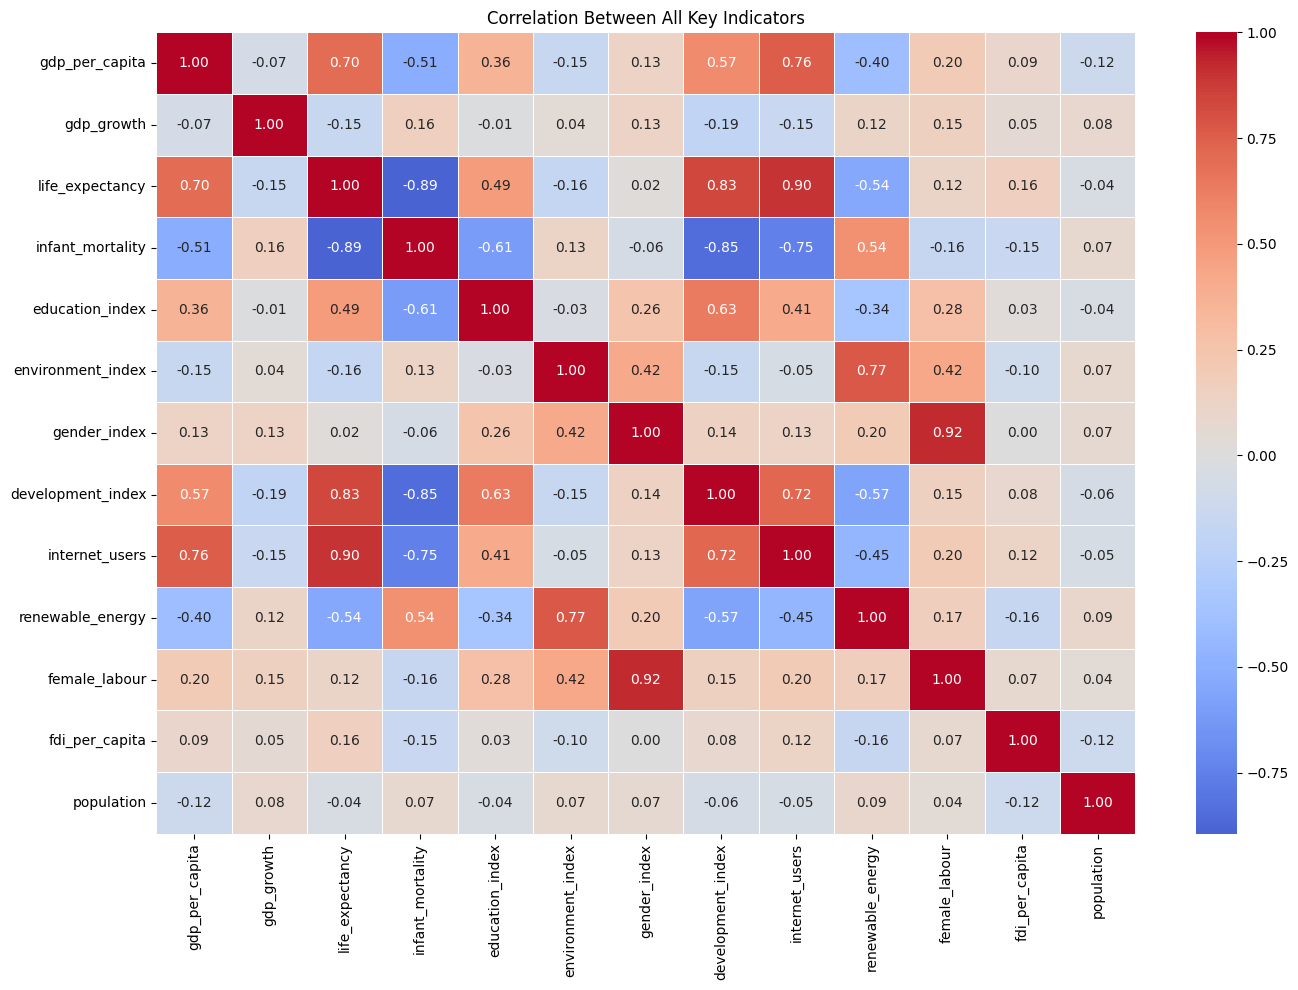

In [143]:
plt.figure(figsize=(14,10))
sns.heatmap(df_corr.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f'
           ,center=0,linewidths=0.5)
plt.title('Correlation Between All Key Indicators')
plt.tight_layout()
plt.show()

#### Strong positive relationships exist between GDP, life expectancy, and development index, while infant mortality shows a strong negative relationship with these factors. This means better economic conditions lead to better health and development outcomes.

### Are rich countries environmentally responsible? High GDP but low renewable energy countries?

In [74]:
df_country_renewable_energy = pd.read_sql("""
SELECT country,AVG(gdp_per_capita) AS avg_gdp, AVG(renewable_energy) AS avg_renewable_energy
FROM "World_Bank"
GROUP BY country
""",engine)
print(df_country_renewable_energy)

                 country       avg_gdp  avg_renewable_energy
0                   Iraq   4098.777917              1.091667
1            Korea, Rep.  25909.529583              2.025000
2              Indonesia   2796.642500             33.429167
3             Bangladesh   1173.100833             41.120833
4             Tajikistan    688.634167             49.366667
5      Brunei Darussalam  31788.861250              2.512500
6                   Oman  18423.738333              0.125000
7     Iran, Islamic Rep.   4578.511250              0.950000
8                  China   6126.695417             15.358333
9                Armenia   3249.444167              7.979167
10              Viet Nam   2022.142917             36.791667
11                 Qatar  66267.102917              0.166667
12              Pakistan   1116.080000             46.616667
13                Jordan   3332.953333              3.787500
14  Syrian Arab Republic   1419.821304              1.608696
15              Cambodia

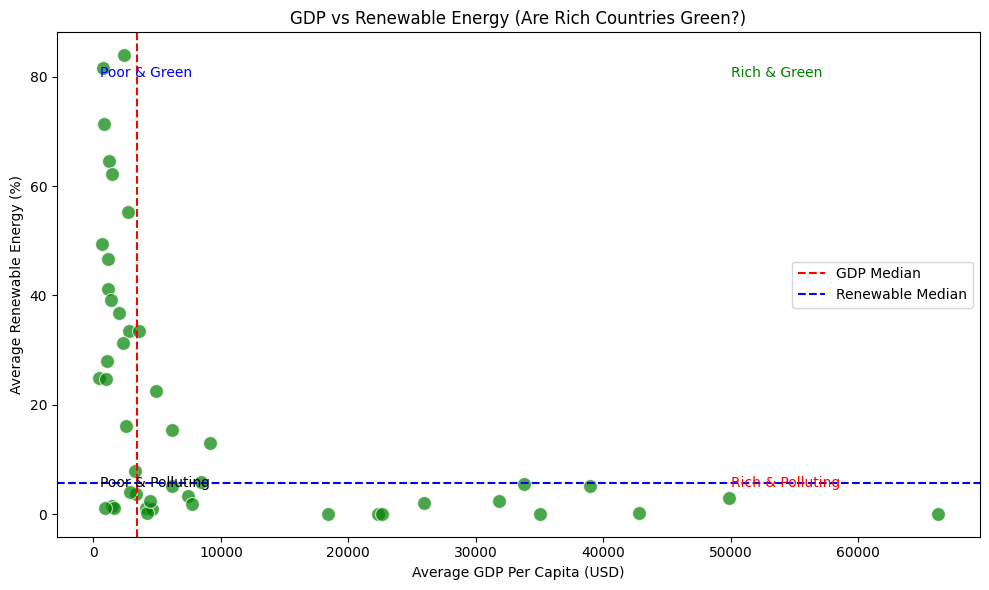

In [146]:
plt.figure(figsize=(10,6))
sns.scatterplot(x = 'avg_gdp',y='avg_renewable_energy',data = df_country_renewable_energy,alpha=0.7, s=100,color='green')
plt.axvline(x=df_country_renewable_energy['avg_gdp'].median(), 
            color='red', linestyle='--', label='GDP Median')
plt.axhline(y=df_country_renewable_energy['avg_renewable_energy'].median(), 
            color='blue', linestyle='--', label='Renewable Median')
plt.text(50000, 80, 'Rich & Green', fontsize=10, color='green')
plt.text(50000, 5, 'Rich & Polluting', fontsize=10, color='red')
plt.text(500, 80, 'Poor & Green', fontsize=10, color='blue')
plt.text(500, 5, 'Poor & Polluting', fontsize=10, color='black')

plt.title('GDP vs Renewable Energy (Are Rich Countries Green?)')
plt.xlabel('Average GDP Per Capita (USD)')
plt.ylabel('Average Renewable Energy (%)')
plt.legend()
plt.tight_layout()
plt.show()



#### Most countries fall into “poor but green” or “rich but less green” categories. Very few countries are both rich and highly dependent on renewable energy, showing a gap in sustainable development.

### Which regions are most balanced in development?
### Health, education, gender, environment by sub region?

In [77]:
df_balanced=pd.read_sql("""
SELECT sub_region,
ROUND(AVG(health_index)::numeric,2) AS health,
ROUND(AVG(education_index)::numeric,2) AS education,
ROUND(AVG(gender_index)::numeric,2) AS gender,
ROUND(AVG(environment_index)::numeric,2) AS environment
FROM "World_Bank"
GROUP BY sub_region
""",engine)
print(df_balanced)

       sub_region  health  education  gender  environment
0  Southeast Asia    0.80      90.42   26.18        55.97
1    Central Asia    0.74      93.55   21.88        36.45
2       West Asia    0.84      93.32   14.99        35.48
3       East Asia    1.00      97.47   23.40        46.12
4      South Asia    0.73      80.40   15.88        52.66


In [78]:
df_melted_balanced= df_balanced.melt(id_vars='sub_region',
                                     value_vars=['health','education','gender','environment']
                                     ,var_name='index_type'
                                     , value_name='score')

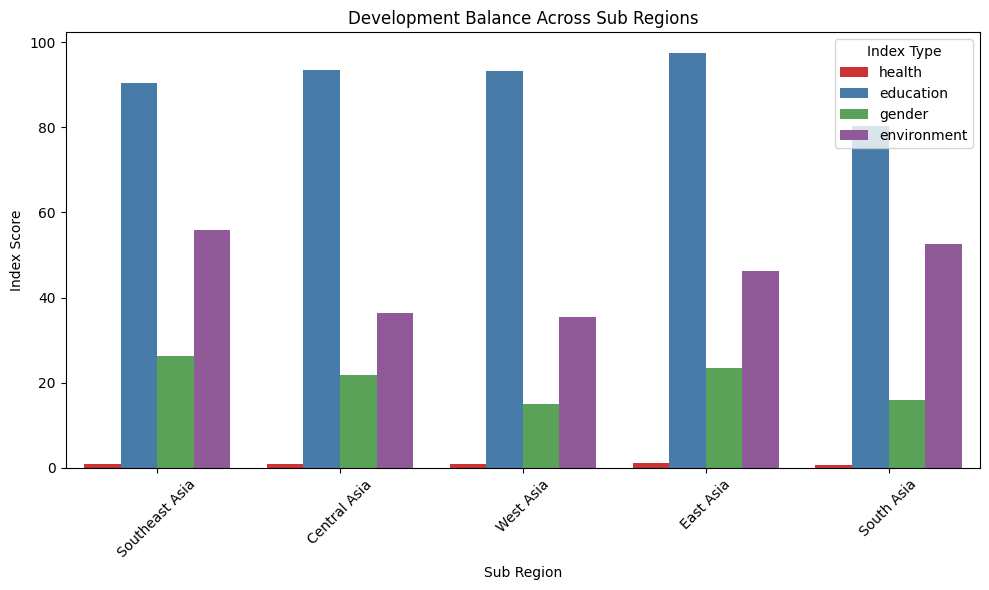

In [148]:
plt.figure(figsize=(10,6))
sns.barplot(x = 'sub_region',y='score',hue = 'index_type',data = df_melted_balanced,palette='Set1')
plt.title('Development Balance Across Sub Regions')
plt.xlabel('Sub Region')
plt.ylabel('Index Score')
plt.xticks(rotation=45)
plt.legend(title='Index Type')
plt.tight_layout()
plt.show()

#### This chart compares multiple development indicators (health, education, gender, and environment) across sub-regions. East Asia performs the best overall, with high scores in education and strong performance in other areas, showing balanced development. Southeast Asia and Central Asia also perform well but slightly lower than East Asia. West Asia shows moderate performance, especially weaker in gender equality. South Asia has the lowest scores in most indicators, particularly in gender and health, indicating developmental challenges. Overall, the chart shows that development is not equal across regions, and some regions lag behind in key areas.

### Which countries are most developed overall?
### Which sub region scores best across all indexes?

In [81]:
df_balanced = pd.read_sql("""
    SELECT sub_region,
           ROUND(AVG(health_index)::numeric, 2) as health,
           ROUND(AVG(education_index)::numeric, 2) as education,
           ROUND(AVG(gender_index)::numeric, 2) as gender,
           ROUND(AVG(environment_index)::numeric, 2) as environment,
           ROUND(AVG(development_index)::numeric, 2) as development
    FROM "World_Bank"
    GROUP BY sub_region;
""", engine)

print(df_balanced)

       sub_region  health  education  gender  environment  development
0  Southeast Asia    0.80      90.42   26.18        55.97        73.38
1    Central Asia    0.74      93.55   21.88        36.45        76.96
2       West Asia    0.84      93.32   14.99        35.48        82.42
3       East Asia    1.00      97.47   23.40        46.12        85.41
4      South Asia    0.73      80.40   15.88        52.66        65.75


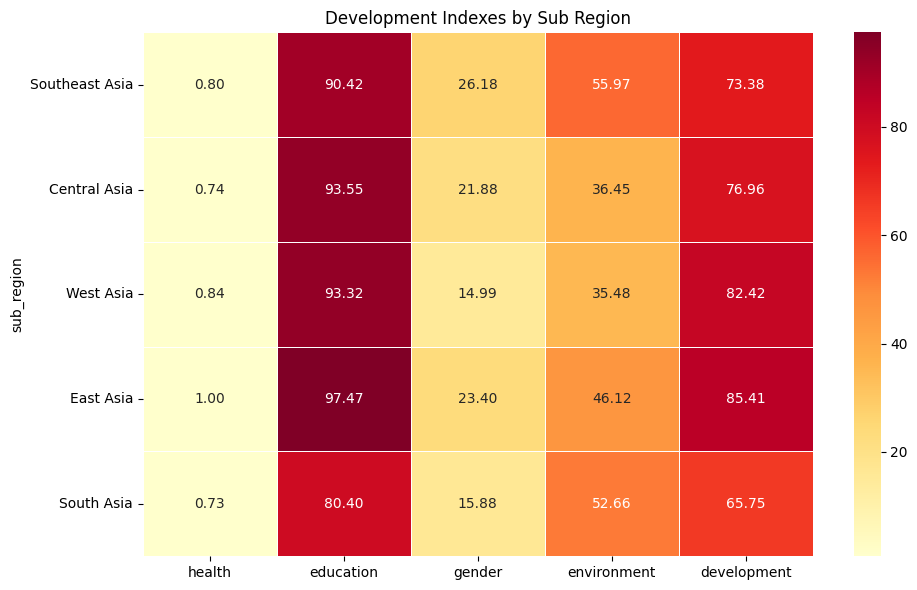

In [149]:
plt.figure(figsize=(10,6))
sns.heatmap(df_balanced.set_index('sub_region'),
            annot=True,
            fmt='.2f',
            cmap='YlOrRd',
            linewidths=0.5)
plt.title('Development Indexes by Sub Region')
plt.tight_layout()
plt.show()

#### The heatmap shows the intensity of different development indicators across sub-regions. East Asia has the highest overall development score, with very strong performance in education and environment. Southeast Asia and Central Asia have moderate to high scores, especially in education. West Asia shows good education levels but lower gender equality scores. South Asia has comparatively lower values in health, gender, and overall development. The variation in colors clearly highlights regional inequalities, with some regions performing consistently better across all indicators while others lag behind.